In [1]:
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer


# =========================
# 1. Load dataset
# =========================
file_path = r"C:\Users\user\Desktop\u\Y3S1\ZCT 398\02. data\Full data.csv"
df = pd.read_csv(file_path)

# Replace missing values with 0 initially
df.fillna(0, inplace=True)


# =========================
# 2. Data cleaning function
# =========================
def clean_value(x):
    """
    Cleans a value by removing non-numeric characters
    and converting it into a float.
    
    If conversion fails, returns 0.
    """
    if pd.isna(x):
        return 0
    
    # Remove everything except numbers, dot, and minus sign
    cleaned_value = re.sub(r'[^\d.-]', '', str(x))
    
    try:
        return float(cleaned_value)
    except ValueError:
        return 0


# =========================
# 3. Feature preprocessing
# =========================
# Select feature columns (based on dataset structure)
feature_columns = df.columns[2:70]

# Apply cleaning function to all feature columns
for col in feature_columns:
    df[col] = df[col].apply(clean_value)

# Replace infinite values and remaining NaNs
df[feature_columns] = df[feature_columns].replace([np.inf, -np.inf], 0)
df[feature_columns] = df[feature_columns].fillna(0)


# =========================
# 4. Create target labels (multi-label classification)
# =========================
# Normalize text labels
df['Pictogram(s)'] = df['Pictogram(s)'].apply(
    lambda x: str(x).lower() if pd.notna(x) else ''
)

# Define hazard categories
outputs = [
    'Irritant',
    'Acute Toxic',
    'Flammable',
    'Corrosive',
    'Health Hazard',
    'Environmental Hazard',
    'Compressed Gas',
    'Explosive',
    'Oxidizer'
]

# Convert text labels into binary columns (multi-label encoding)
for output in outputs:
    df[output] = df['Pictogram(s)'].apply(
        lambda x: 1 if output.lower() in x.lower() else 0
    )


# =========================
# 5. Train-test split
# =========================
X = df[feature_columns].astype(float)
y = df[outputs]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =========================
# 6. Handle missing and infinite values
# =========================
imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Replace any remaining infinities
X_train = np.where(np.isinf(X_train), 0, X_train)
X_test = np.where(np.isinf(X_test), 0, X_test)


# =========================
# 7. Feature scaling
# =========================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================
# 8. Train Random Forest model (multi-label baseline)
# =========================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


# =========================
# 9. Global feature importance
# =========================
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


# =========================
# 10. Feature importance per output class
# =========================
for output in outputs:
    print(f"Feature Importance for {output}:")

    # Train separate model for each label
    y_train_output = y_train[output]

    rf_output = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_output.fit(X_train, y_train_output)

    output_importances = rf_output.feature_importances_

    output_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': output_importances
    }).sort_values(by='Importance', ascending=False)

    print(output_importance_df)
    print("\n")


# =========================
# 11. Extract Top 5 features per output
# =========================
top5_results = []

for output in outputs:
    y_train_output = y_train[output]

    rf_output = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_output.fit(X_train, y_train_output)

    output_importances = rf_output.feature_importances_

    output_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': output_importances
    }).sort_values(by='Importance', ascending=False)

    # Keep only top 5 features
    top5 = output_importance_df.head(5).copy()
    top5['Output'] = output

    top5_results.append(top5)


# Combine results across all outputs
top5_all_outputs = pd.concat(top5_results, ignore_index=True)
top5_all_outputs = top5_all_outputs[['Output', 'Feature', 'Importance']]


# =========================
# 12. Export results
# =========================
export_path = r"C:\Users\user\Desktop\u\Y3S1\ZCT 398\03. features selection\top5_feature_importances.csv"
top5_all_outputs.to_csv(export_path, index=False)

print("Exported feature importance results successfully!")

C:\Users\user\AppData\Local\Temp\ipykernel_5744\4120312589.py:13: DtypeWarning: Columns (4,8,10,13,17,18,19,22,24,27,28,29,34,38,40,41,49,54,56,60,61,62,66,71,77,78,80,82) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1163: RuntimeWarning: overflow encountered in square
  temp **= 2
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
C:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:88: RuntimeWarning: overflow encountered in square
  upper_bound = n_samples * eps * var + (n_samples * mean * eps) ** 2


Feature Importance for Irritant:
                           Feature  Importance
61                      Complexity    0.133947
30                          XLogP3    0.110041
18               Monoisotopic Mass    0.107859
40  Topological Polar Surface Area    0.105511
10                      Exact Mass    0.105005
..                             ...         ...
56            Endocrine Disruptors    0.000000
8                 Flame Retardants    0.000000
54             Dielectric Constant    0.000000
20    SpringerMaterials Properties    0.000000
7                         Polymers    0.000000

[68 rows x 2 columns]


Feature Importance for Acute Toxic:
                           Feature  Importance
61                      Complexity    0.125011
10                      Exact Mass    0.113031
18               Monoisotopic Mass    0.112400
50                Molecular Weight    0.108815
40  Topological Polar Surface Area    0.107044
..                             ...         ...
54           

C:\Users\user\AppData\Local\Temp\ipykernel_25156\896589606.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_features, rotation=45, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_25156\896589606.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_features, rotation=45, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_25156\896589606.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_features, rotation=45, ha='right')
C:\Users\user\AppData\Local\Temp\ipykernel_25156\896589606.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_features, rotation=

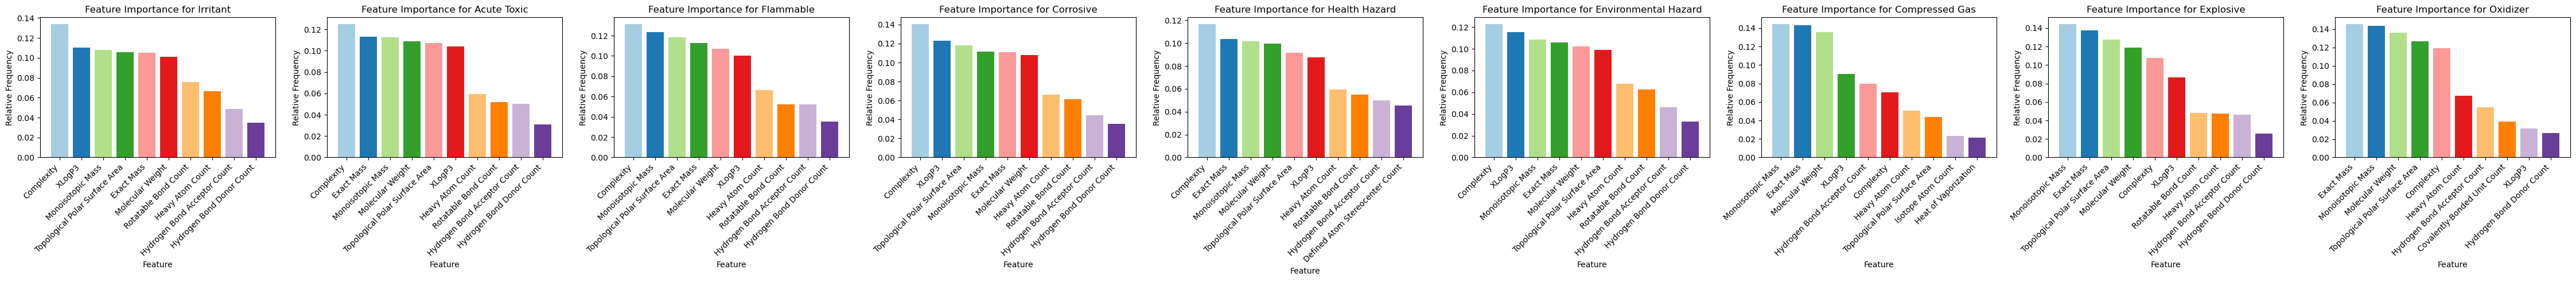

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier


# =========================
# 1. Feature Importance Plot Function
# =========================
def plot_feature_importance(output_name, feature_importances, features, ax, top_n=10):
    """
    Plots the top N feature importances for a given output class.

    Parameters:
    - output_name (str): Name of the target class
    - feature_importances (array): Importance values from Random Forest
    - features (list): Feature names
    - ax (matplotlib axis): Plot axis to draw on
    - top_n (int): Number of top features to display
    """

    # Normalize importance values (optional interpretation)
    relative_importances = feature_importances / np.sum(feature_importances)

    # Get indices of top N features
    top_idx = np.argsort(feature_importances)[-top_n:][::-1]

    # Extract feature names and values
    top_features = np.array(features)[top_idx]
    top_importances = feature_importances[top_idx]

    # Create bar plot
    ax.bar(
        top_features,
        top_importances,
        color=plt.cm.Paired.colors[:len(top_features)]
    )

    # Plot labels and title
    ax.set_title(f"Feature Importance for {output_name}")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Importance")

    # Rotate x-axis labels for readability
    ax.set_xticklabels(top_features, rotation=45, ha='right')


# =========================
# 2. Create subplots for all outputs
# =========================
fig, axes = plt.subplots(1, len(outputs), figsize=(5 * len(outputs), 5))
axes = axes.flatten()


# =========================
# 3. Train model per output + plot importance
# =========================
for i, output in enumerate(outputs):

    # Train separate Random Forest model for each label
    y_train_output = y_train[output]

    rf_output = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_output.fit(X_train, y_train_output)

    # Get feature importance
    output_importances = rf_output.feature_importances_

    # Plot in subplot
    plot_feature_importance(
        output,
        output_importances,
        X.columns,
        axes[i]
    )

    # =========================
    # 4. Save individual plot per output
    # =========================
    fig_single = plt.figure()
    ax_single = fig_single.add_subplot(111)

    plot_feature_importance(
        output,
        output_importances,
        X.columns,
        ax_single
    )

    filename = f"feature_importance_{output}.jpg"
    fig_single.savefig(filename, format='jpg', dpi=300, bbox_inches='tight')

    plt.close(fig_single)


# =========================
# 5. Final layout display
# =========================
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier


# =========================
# 1. Store top features per output class
# =========================
top5_results = []

# Loop through each target output (multi-label case)
for output in outputs:

    # Select target column for current class
    y_train_output = y_train[output]

    # Train a separate Random Forest model for this output
    rf_output = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_output.fit(X_train, y_train_output)

    # Extract feature importance values
    output_importances = rf_output.feature_importances_

    # Create a DataFrame mapping features to importance scores
    output_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': output_importances
    }).sort_values(by='Importance', ascending=False)

    # Keep only top 5 most important features
    top5 = output_importance_df.head(5).copy()

    # Tag with output class name
    top5['Output'] = output

    # Store result
    top5_results.append(top5)


# =========================
# 2. Combine all outputs into one table
# =========================
top5_all_outputs = pd.concat(top5_results, ignore_index=True)

# Reorder columns for clarity
top5_all_outputs = top5_all_outputs[['Output', 'Feature', 'Importance']]


# =========================
# 3. Export results to CSV
# =========================
export_path = r"C:\Users\user\Desktop\u\Y3S1\ZCT 398\03. features selection\top5_feature_importances.csv"
top5_all_outputs.to_csv(export_path, index=False)

print("Feature selection export completed successfully!")

Exported!
